# Prophet Forecast

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from prophet import Prophet

# 1. Load data
df = pd.read_csv("../datasets/delivery_clean_data.csv")

# 2. PROPHET REQUIREMENT:
# Prophet strictly requires a dataframe with exactly two columns named:
# 'ds' (datestamp) and 'y' (the numeric value to predict)
prophet_df = df.rename(columns={"date": "ds", "deliveries": "y"})
prophet_df["ds"] = pd.to_datetime(prophet_df["ds"])

prophet_df.head()

,ds,y
0,2025-01-01,128
1,2025-01-02,124
2,2025-01-03,130
3,2025-01-04,97
4,2025-01-05,83


In [4]:
# 1. Initialize and Fit the Model
# We explicitly turn on weekly seasonality since we identified it on Day 2
model = Prophet(yearly_seasonality=True, weekly_seasonality=True)
model.fit(prophet_df)

# 2. Create a Future Dataframe extending 30 days out
future = model.make_future_dataframe(periods=30, freq="D")

# 3. Predict the Future
forecast = model.predict(future)

# Look at the key forecast columns: Predicted value (yhat), lower bound, and upper bound
forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail()

14:41:43 - cmdstanpy - INFO - Chain [1] start processing
14:41:43 - cmdstanpy - INFO - Chain [1] done processing


,ds,yhat,yhat_lower,yhat_upper
525,2026-06-10,208.973888,196.577315,221.920201
526,2026-06-11,210.377172,197.925679,223.680189
527,2026-06-12,208.965416,196.974958,221.410272
528,2026-06-13,170.204569,157.492403,182.251549
529,2026-06-14,169.035716,156.274889,182.991893


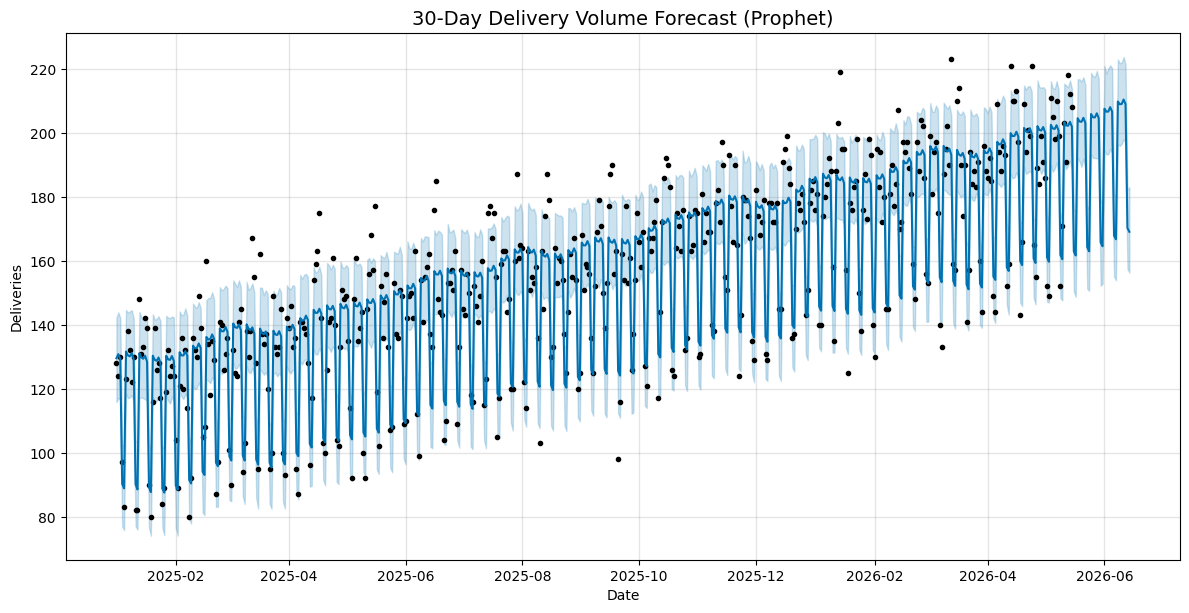

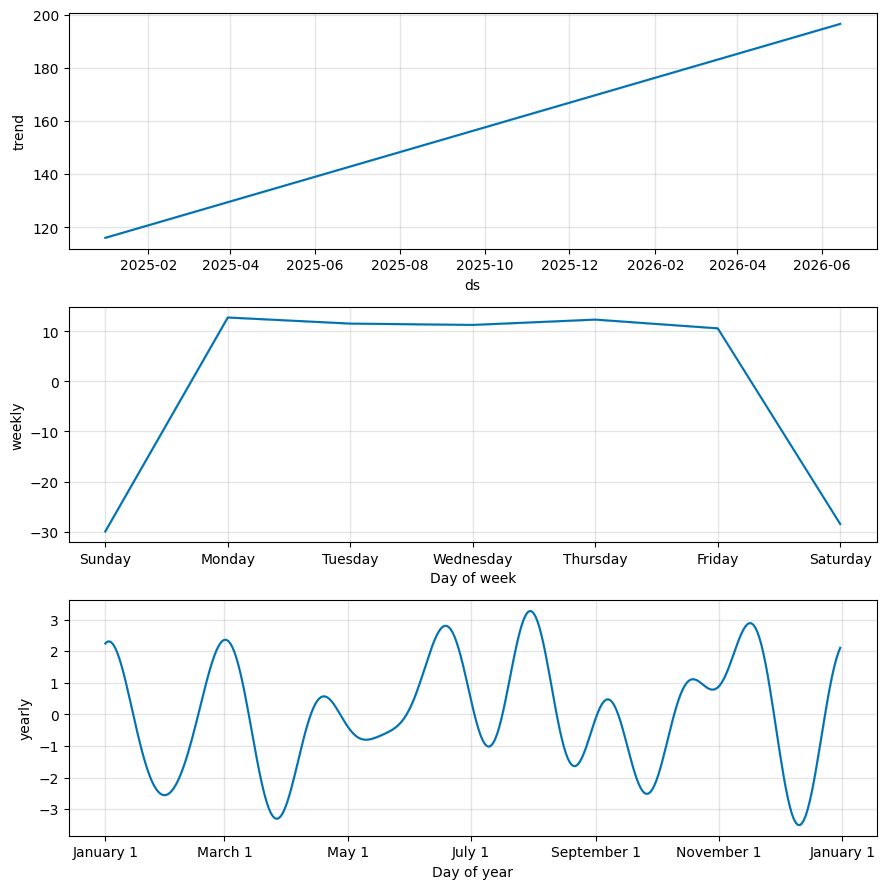

In [5]:
# Plot 1: Main Forecast Plot
# Black dots = actual data points, Blue line = the model's forecast, Light blue shade = uncertainty interval
fig1 = model.plot(forecast, figsize=(12, 6))
plt.title("30-Day Delivery Volume Forecast (Prophet)", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Deliveries")
plt.show()

# Plot 2: Forecast Components
# Breaks down the overall trend, weekly pattern, and yearly pattern calculated by Prophet
fig2 = model.plot_components(forecast)
plt.show()